In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import ICIW_Plots

plt.style.use("ICIWstyle")
plt.rcParams["font.size"] = 7

In [2]:
n_dot = np.load(r"C:\Users\FranzBraun\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_ges_sys_280C_320C\RTD_250ml_min_matrix_250_MS_composition_with_GC.npy")
t_source = np.load(r"C:\Users\FranzBraun\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_ges_sys_280C_320C\RTD_250ml_min_matrix_250_MS_times_with_GC.npy")

In [3]:
print(n_dot.shape)

(149166, 3)


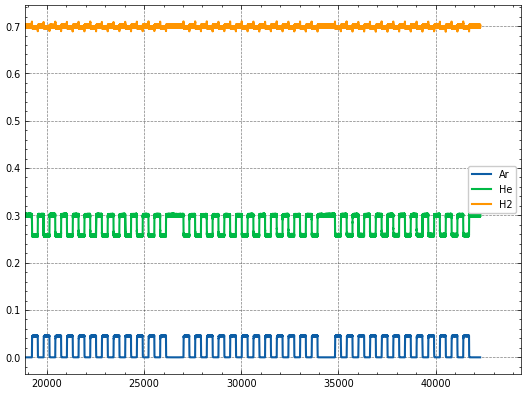

In [16]:
plt.plot(t_source, n_dot[:,0], label="Ar", color="C0")
plt.plot(t_source, n_dot[:,1], label="He", color="C1")
plt.plot(t_source, n_dot[:,2], label="H2", color="C2")
plt.xlim(-20.25+45*60+12*10*60+20*60+12*10*60+10*60,)
plt.legend()

In [17]:
time_delta = t_source - t_source[0]

np.savez(
    r"C:\Users\FranzBraun\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_ges_sys_280C_320C\FBA_250ml-min_2bar_250_TotalSystem.npz",
    n_dot=n_dot.T,
    time_delta=time_delta,
)

t_range = (time_delta.min(), time_delta.max())

In [20]:
# create array with half-period times

t_offset = -20.25+45*60+12*10*60+20*60+12*10*60+10*60 # 45min offset until experiment starts
t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((24,), t_halfperiod) # 24 half-periods
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[18879 19179 19479 19779 20079 20379 20679 20979 21279 21579 21879 22179
 22479 22779 23079 23379 23679 23979 24279 24579 24879 25179 25479 25779
 26079]
[(np.int64(18879), np.int64(19179)), (np.int64(19179), np.int64(19479)), (np.int64(19479), np.int64(19779)), (np.int64(19779), np.int64(20079)), (np.int64(20079), np.int64(20379)), (np.int64(20379), np.int64(20679)), (np.int64(20679), np.int64(20979)), (np.int64(20979), np.int64(21279)), (np.int64(21279), np.int64(21579)), (np.int64(21579), np.int64(21879)), (np.int64(21879), np.int64(22179)), (np.int64(22179), np.int64(22479)), (np.int64(22479), np.int64(22779)), (np.int64(22779), np.int64(23079)), (np.int64(23079), np.int64(23379)), (np.int64(23379), np.int64(23679)), (np.int64(23679), np.int64(23979)), (np.int64(23979), np.int64(24279)), (np.int64(24279), np.int64(24579)), (np.int64(24579), np.int64(24879)), (np.int64(24879), np.int64(25179)), (np.int64(25179), np.int64(25479)), (np.int64(25479), np.int64(25779)), (np.int64(25779),

In [21]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot.T,
    kind="linear",
    fill_value="extrapolate",
)

In [22]:
t = np.linspace(*t_range, 481)
n_dot_interp = interp(t)

<>:5: SyntaxWarning: invalid escape sequence '\;'
<>:6: SyntaxWarning: invalid escape sequence '\;'
<>:5: SyntaxWarning: invalid escape sequence '\;'
<>:6: SyntaxWarning: invalid escape sequence '\;'
C:\Users\FranzBraun\AppData\Local\Temp\ipykernel_12140\1115985599.py:5: SyntaxWarning: invalid escape sequence '\;'
  xlabel="$t\;/\;\mathrm{s}$",
C:\Users\FranzBraun\AppData\Local\Temp\ipykernel_12140\1115985599.py:6: SyntaxWarning: invalid escape sequence '\;'
  ylabel="$x\;/\; 1$",


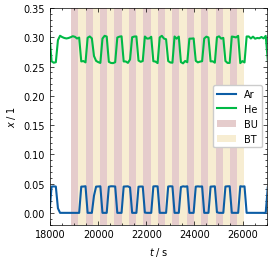

In [24]:
fig = plt.figure()
ax = ICIW_Plots.make_square_ax(
    fig=fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel="$t\;/\;\mathrm{s}$",
    ylabel="$x\;/\; 1$",
    xlim=(18000, 27000),
    ylim=(-0.02, 0.35),
)
ax.grid(False)
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")


for interval in intervals[::2]:
    plt.fill_betweenx(
        [-0.1, 0.4],
        interval[0],
        interval[1],
        alpha=0.2,
        color="maroon",
        edgecolor=None,
        zorder=-1,
        label="BU",
    )
for interval in intervals[1::2]:
    plt.fill_betweenx(
        [-0.1, 0.4],
        interval[0],
        interval[1],
        alpha=0.2,
        color="goldenrod",
        edgecolor=None,
        zorder=-1,
        label="BT",
    )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig("exp_data_with_halfperiods.png", dpi=600)